# Data-reduction & compute evaluation — mask-driven real-time collection

**Question 1 (data reduction):** how much storage does mask-driven real-time collection save
vs. naively capturing every sample — *and at what cost to signal fidelity*?
**Question 2 (compute):** what does each detector cost to run in real time (GPU-accelerated
deployment) — FLOPs + GPU memory — vs. its detection performance?

All numbers are **hand-calcs derived from the detector masks** over the attenuation-sweep
("wired") captures. Everything is documented inline: baseline, formulas, assumptions.

## Methodology
**Baseline (save-all).** Captures are 245.76 MHz complex, `cf32` (8 B/sample):
`SAVE_ALL = 245.76e6 · 8 · 3600 = 7.08 TB/hour` (flat — SNR-independent).

**Three reduction strategies** (increasing aggressiveness):
1. **Save-all** — 7.08 TB/hr.
2. **Time-slicing** — keep only time-blocks containing ≥1 detected mask cell.
   `bytes/hr = SAVE_ALL · timeslice_frac`. Block size is a knob (default = mask time-row
   ≈ 42 µs; coarser → keep more). Modest win (signals are temporally spread).
3. **Rational resample + frequency filter** — per detected region, keep only its bandwidth
   resampled to baseband over its duration. The big win. The *actual* resample/filter operator
   is a **collaborator hook** (`resample_filter_bytes_per_hour`, below); here we plot a
   **projection from raw-mask TF-coverage** as an indicative bound.

**Signal retention (fidelity).** Of a signal's occupied time-rows, the fraction the detector's
mask also flags (so that slot is kept): `retention = |GT_rows ∩ det_rows| / |GT_rows|`.
Coherent-power is the **baseline to beat** — it is *supposed* to emit a mask even if unoptimized.

**Compute.** FLOP estimates + measured GPU memory + real-time throughput (vs the 245.76 MS/s bar),
from `compute_table.csv` (see `yolo_training/src/measure_compute.py`). Container-only detectors
(coherent, zero-shot) are FLOP/mem estimates.

In [1]:
import os, re, glob, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import ndimage
warnings.filterwarnings("ignore")

HSD        = Path.home() / "Holohub-Signal-Detection"
SWEEP      = Path(os.environ.get("DS_SWEEP", str(HSD / "notebooks/yolo_evals/sweeps/sweep_all")))
TABLES     = HSD / "notebooks/yolo_evals/compare_tables"        # IoU (frame_pixel_metrics)
COMPUTE_CSV= Path(__file__).parent / "compute_table.csv" if "__file__" in dir() else Path("compute_table.csv")

# ---- baseline geometry (the save-all reference) ----
RATE_HZ, BYTES_PER_SAMPLE, SEC_PER_HR = 245.76e6, 8, 3600
SAVE_ALL_BYTES_HR = RATE_HZ * BYTES_PER_SAMPLE * SEC_PER_HR      # 7.08 TB/hr
NFFT = 10240                                                    # batch-frame freq bins
N_FRAMES = int(os.environ.get("DS_NFRAMES", "120"))             # frames/stem sampled

DETS   = ["coherent_power","cuda_dino","finetuned_dino","finetuned_dino_m2","yolo26s","yolo26m"]
LABEL  = {"coherent_power":"Coherent Power","cuda_dino":"Zero-shot DINOv3",
          "finetuned_dino":"FT-DINO M1","finetuned_dino_m2":"FT-DINO M2",
          "yolo26s":"YOLO26s","yolo26m":"YOLO26m"}
COLOR  = {"coherent_power":"#d95f02","cuda_dino":"#7570b3","finetuned_dino":"#1b9e77",
          "finetuned_dino_m2":"#e7298a","yolo26s":"#66a61e","yolo26m":"#a6761d"}
print(f"SAVE-ALL baseline = {SAVE_ALL_BYTES_HR/1e12:.2f} TB/hour  |  real-time rate = {RATE_HZ/1e6:.2f} MS/s")

SAVE-ALL baseline = 7.08 TB/hour  |  real-time rate = 245.76 MS/s


## 1. Data-reduction hand-calc engine
Detector masks are first **denoised** (drop connected components < `MIN_BOX_PIXELS`=256, matching
`signal_snipper`). Per (detector, capture) we then derive: `timeslice_frac` (fraction of time-blocks kept),
`tf_coverage` (fraction of the time-frequency plane on → projected resample+filter footprint), and
`retention` (fraction of GT signal-time kept). `attenuation_dB_30` and `_30_v2` are averaged to 30 dB.

In [2]:
def _load(p):
    z = np.load(p); return np.unpackbits(z["packed"])[:int(z["rows"])*int(z["cols"])].reshape(int(z["rows"]), int(z["cols"]))

def timeslice_frac(mask, block_rows=1):
    r = mask.shape[0]; nb = r // block_rows
    return mask[:nb*block_rows].reshape(nb, block_rows, -1).any(axis=(1, 2)).mean()

# Detector masks are DENOISED before every data-reduction metric, matching what signal_snipper keeps:
# it drops connected components smaller than min_box_pixels (config default 256) as speckle. Raw
# "any on-pixel in a time-row" over-counts a noisy detector -- at high attenuation a single stray pixel
# per row flags ~every row as "keep", so time-slicing looked like it saved nothing (it should save more
# as the signal fades). We keep the raw value too (timeslice_frac_raw) to show the difference.
MIN_BOX_PIXELS = int(os.environ.get("DS_MIN_BOX_PIXELS", "256"))  # == signal_snipper.min_box_pixels

def denoise(mask):
    """Drop connected components smaller than MIN_BOX_PIXELS (speckle), like the snipper's clustering."""
    if MIN_BOX_PIXELS <= 1 or not mask.any():
        return mask
    lab, nl = ndimage.label(mask)
    if nl == 0:
        return np.zeros_like(mask)
    sizes = ndimage.sum(np.ones_like(mask, dtype=np.float32), lab, index=np.arange(1, nl + 1))
    keep = np.zeros(nl + 1, dtype=bool); keep[1:] = sizes >= MIN_BOX_PIXELS
    return keep[lab].astype(mask.dtype)

# ---- resample+filter: MEASURED from the signal_snipper operator ----
# signal_snipper (frequency mode) IS the rational-resample/frequency-filter operator: it cuts each
# detected signal out of the wideband IQ, mixes to baseband, low-passes to the signal bandwidth, and
# decimates; sigmf_file_sink then writes the result as SigMF. Run it offline over captures with
#   applications/usrp_wideband_signal_detection/bash_scripts/run_offline_snipper.sh
# (needs the container / lab-admin sudo). Snippets land at
#   ${SNIP_ROOT}/<detector>/<capture-stem>/snippets/*.sigmf-data
# and the measured resample+filter footprint is just those bytes scaled to an hour of capture.
SNIP_ROOT = Path(os.environ.get("DS_SNIP_ROOT", "/tmp/usrp_spectrograms/snippets_eval"))

def snippet_bytes(detector, stem):
    """Total SigMF data bytes the snipper emitted for one (detector, capture), or None if not run yet."""
    d = SNIP_ROOT / detector / stem / "snippets"
    if not d.exists():
        return None
    b = sum(f.stat().st_size for f in d.rglob("*.sigmf-data"))
    return b if b > 0 else None

def resample_filter_bytes_per_hour(detector, stem, capture_sec):
    """MEASURED resample+filter footprint (bytes/hr) from the signal_snipper's SigMF output. Returns
    None when the snipper hasn't been run for this (detector, stem) yet -- callers then fall back to
    the raw-mask TF-coverage projection. (Was a NotImplementedError stub; now wired to the real
    operator via bash_scripts/run_offline_snipper.sh.)"""
    b = snippet_bytes(detector, stem)
    return None if (b is None or capture_sec <= 0) else b / capture_sec * SEC_PER_HR

def atten(stem):
    m = re.search(r"dB_(\d+)", stem); return int(m.group(1)) if m else None

rows = []
for det in DETS:
    for sd in sorted((SWEEP/det).glob("*/")):
        a = atten(sd.name)
        if a is None: continue
        mfiles = sorted(sd.glob("mask_arrays/mask_ch0_f*.packed.npz"))[:N_FRAMES]
        ts, ts_raw, cov, ret = [], [], [], []
        for mf in mfiles:
            n = re.search(r"_f(\d+)_", mf.name).group(1)
            m = _load(mf); md = denoise(m)                      # md = what the snipper would keep
            ts.append(timeslice_frac(md)); ts_raw.append(timeslice_frac(m)); cov.append((md != 0).mean())
            gtf = list(sd.glob(f"gt_masks/*_f{n}_*.packed.npz"))
            if gtf:
                g = _load(gtf[0]); gr = g.any(axis=1)
                if gr.any(): ret.append((gr & md.any(axis=1)).sum() / gr.sum())
        rows.append(dict(detector=det, attenuation_db=a,
                         timeslice_frac=np.mean(ts), timeslice_frac_raw=np.mean(ts_raw),
                         tf_coverage=np.mean(cov), retention=np.mean(ret) if ret else np.nan))
raw = pd.DataFrame(rows)
ds = raw.groupby(["detector","attenuation_db"], as_index=False).mean(numeric_only=True)  # avg 30 & 30_v2
ds["saveall_TB_hr"]   = SAVE_ALL_BYTES_HR/1e12
ds["timeslice_TB_hr"] = SAVE_ALL_BYTES_HR*ds.timeslice_frac/1e12
ds["resample_proj_TB_hr"] = SAVE_ALL_BYTES_HR*ds.tf_coverage/1e12     # projection (hook = real operator)
ds["reduction_x"]     = ds.saveall_TB_hr/ds.timeslice_TB_hr
ds.to_csv("data_reduction_table.csv", index=False)
print(f"{len(ds)} (detector, attenuation) rows | strategies: save-all, time-slice, resample-proj(hook)")
display(ds[ds.detector.isin(["coherent_power","finetuned_dino_m2","yolo26m"])]
        .pivot_table(index="detector", columns="attenuation_db", values="timeslice_TB_hr").round(2))

78 (detector, attenuation) rows | strategies: save-all, time-slice, resample-proj(hook)


attenuation_db,0,5,10,15,20,25,30,35,40,45,50,55,60
detector,,,,,,,,,,,,,
coherent_power,3.02,2.73,2.43,1.97,1.59,1.17,1.04,0.85,0.69,0.56,0.28,0.15,0.14
finetuned_dino_m2,3.75,3.64,3.63,3.71,3.62,3.68,3.67,3.76,3.75,3.62,3.74,3.38,2.06
yolo26m,3.57,3.53,3.54,3.58,3.50,3.60,3.52,3.69,3.65,3.57,3.64,3.43,2.90


### Time-slice metric: raw any-pixel vs denoised (why high-attenuation saving looked wrong)
`timeslice_frac` keeps a time-block if it contains a detection. On the RAW mask a single stray noise
pixel flags the whole time-row, so a barely-firing detector looked like it kept ~all the time (saved
nothing) at high attenuation. We now denoise first (drop connected components < `MIN_BOX_PIXELS`=256,
matching `signal_snipper`). That fixes **coherent_power** (att 60: ~0.47 -> ~0.02 kept -> ~98% saved).
**cuda_dino** still keeps ~all the time at high attenuation -- not speckle, but a few persistent
narrowband tone-streaks spanning the whole time axis (a real property of the zero-shot detector's
output, and good motivation for the fine-tuned models).

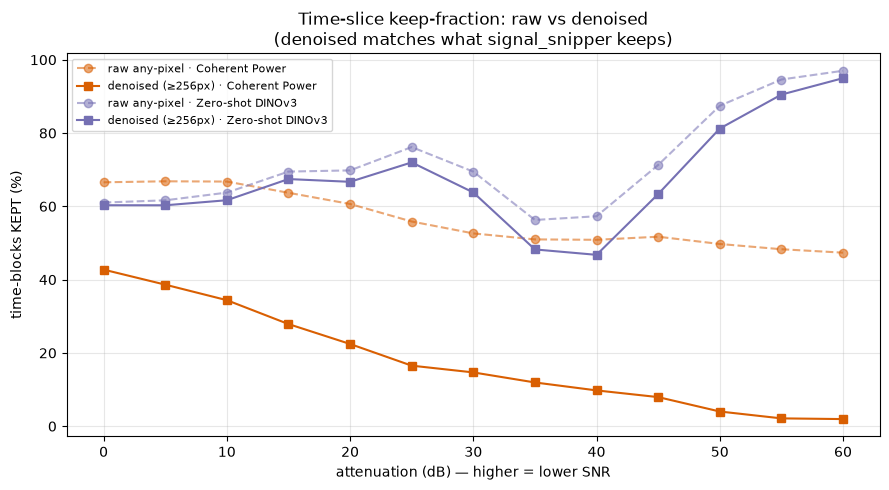

In [3]:
def fig_timeslice_denoise(fname="fig_timeslice_raw_vs_denoised.png"):
    fig, ax = plt.subplots(figsize=(9, 5))
    for det in ("coherent_power", "cuda_dino"):
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, 100*d.timeslice_frac_raw, "--o", color=COLOR[det], alpha=.55,
                label=f"raw any-pixel · {LABEL[det]}")
        ax.plot(d.attenuation_db, 100*d.timeslice_frac, "-s", color=COLOR[det],
                label=f"denoised (≥{MIN_BOX_PIXELS}px) · {LABEL[det]}")
    ax.set_xlabel("attenuation (dB) — higher = lower SNR"); ax.set_ylabel("time-blocks KEPT (%)")
    ax.set_title("Time-slice keep-fraction: raw vs denoised\n(denoised matches what signal_snipper keeps)")
    ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
fig_timeslice_denoise()

### Measured resample+filter (signal_snipper) across the wired attenuation sweep
Same real operator as Figure 3c, applied to the attenuation captures (`~/captures/attenuation_dB_*`).
`resample_meas_TB_hr` fills in per (detector, attenuation) once the snipper has been run for that
detector. Container detectors `coherent_power` / `cuda_dino` are snipper-capable; offline-only models
(FT-DINO M1/M2, YOLO26s/m) make masks in Python and can't be snipped by the container binary, so they
stay NaN here and fall back to the projection in Figure 1. Produce runs per instructions.md.

In [4]:
CAPTURES_DIR = Path(os.environ.get("DS_CAPTURES_DIR", str(Path.home()/"captures")))
def _stems_for_db(db):
    return ["attenuation_dB_30","attenuation_dB_30_v2"] if db == 30 else [f"attenuation_dB_{db}"]
def capture_sec(stem):
    f = CAPTURES_DIR/f"{stem}.sigmf-data"
    return (f.stat().st_size / (BYTES_PER_SAMPLE*RATE_HZ)) if f.exists() else np.nan
def meas_resample_TB_hr(detector, db):
    tot_b, tot_s, found = 0.0, 0.0, False
    for st in _stems_for_db(db):
        b = snippet_bytes(detector, st); sec = capture_sec(st)
        if b is not None and np.isfinite(sec) and sec > 0:
            tot_b += b; tot_s += sec; found = True
    return (tot_b/tot_s*SEC_PER_HR/1e12) if found else np.nan
ds["resample_meas_TB_hr"] = [meas_resample_TB_hr(d, a) for d, a in zip(ds.detector, ds.attenuation_db)]
_nmeas = int(ds.resample_meas_TB_hr.notna().sum())
print(f"measured resample+filter: {_nmeas}/{len(ds)} (detector,attenuation) cells populated "
      + ("-> run bash_scripts/run_offline_snipper.sh over ~/captures/attenuation_dB_* (see instructions.md)"
         if _nmeas == 0 else "(container detectors snipped; offline models stay projected)"))
display(ds.pivot_table(index="detector", columns="attenuation_db", values="resample_meas_TB_hr").round(3))

measured resample+filter: 0/78 (detector,attenuation) cells populated -> run bash_scripts/run_offline_snipper.sh over ~/captures/attenuation_dB_* (see instructions.md)


attenuation_db
detector


## Figure 1 — bytes/hour vs SNR: save-all vs time-slice vs resample+filter (projected)
Coherent Power and fine-tuned DINO (per spec); log-scale bytes. Resample+filter is the projected
raw-mask-coverage bound — the real operator is the collaborator hook.

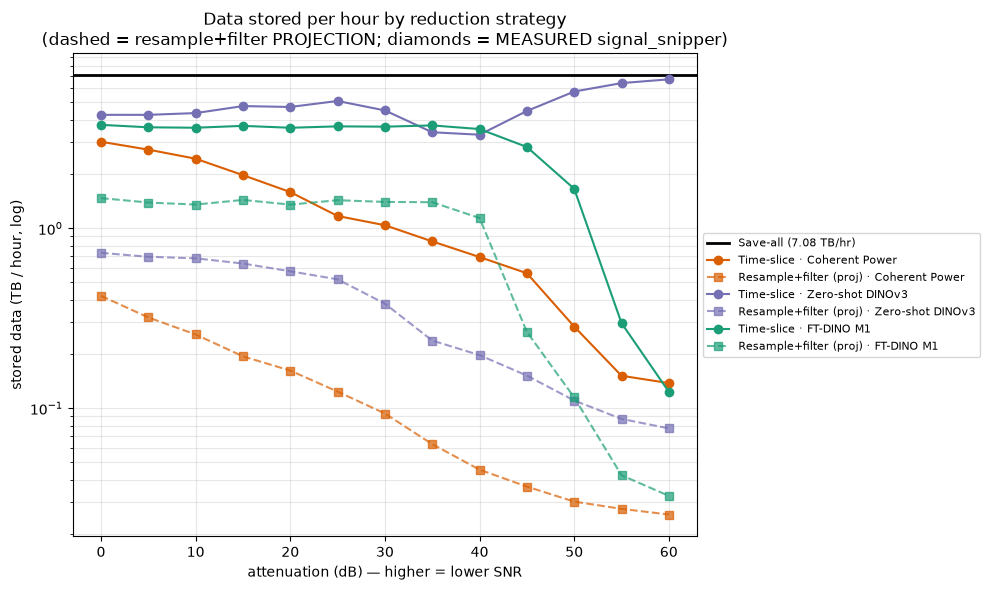

In [5]:
def fig1(dets=("coherent_power","cuda_dino","finetuned_dino"), fname="fig1_bytes_per_hour.png"):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = sorted(ds.attenuation_db.unique())
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="k", ls="-", lw=2, label="Save-all (7.08 TB/hr)")
    for det in dets:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, d.timeslice_TB_hr, "-o", color=COLOR[det], label=f"Time-slice · {LABEL[det]}")
        ax.plot(d.attenuation_db, d.resample_proj_TB_hr, "--s", color=COLOR[det], alpha=.7,
                label=f"Resample+filter (proj) · {LABEL[det]}")
        mm = d.dropna(subset=["resample_meas_TB_hr"])
        if len(mm):
            ax.plot(mm.attenuation_db, mm.resample_meas_TB_hr, "-D", color=COLOR[det], ms=6,
                    label=f"Resample+filter (MEASURED) · {LABEL[det]}")
    ax.set_yscale("log"); ax.set_xlabel("attenuation (dB) — higher = lower SNR")
    ax.set_ylabel("stored data (TB / hour, log)"); ax.grid(alpha=.3, which="both")
    ax.set_title("Data stored per hour by reduction strategy\n(dashed = resample+filter PROJECTION; diamonds = MEASURED signal_snipper)")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1, .5)); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
fig1()

## Figure — reduction vs retention (the honest trade-off)
Saving bytes by dropping un-flagged data only helps if the *signal* is kept. X = data-reduction
factor (× vs save-all, time-slice strategy); Y = signal-time retention. Up-and-right is better.

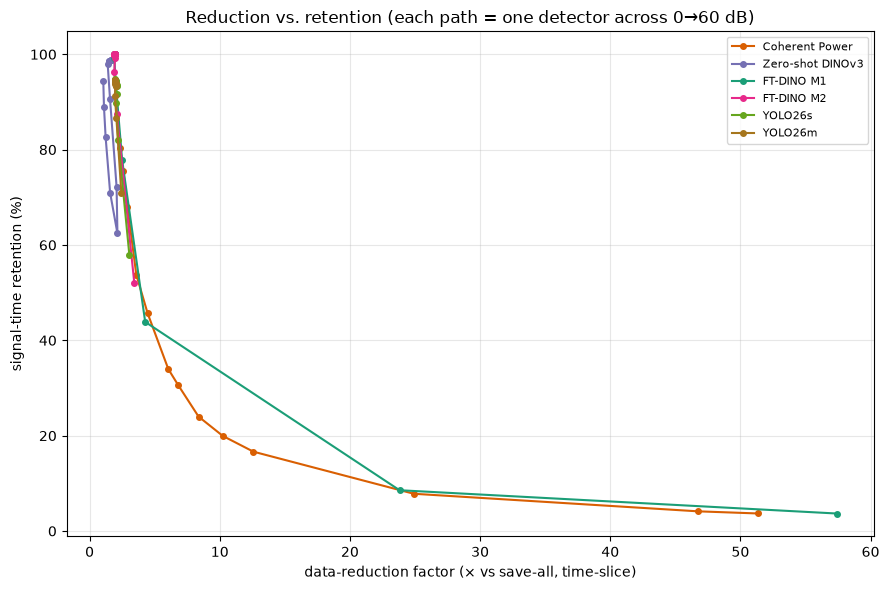

In [6]:
def fig_tradeoff(fname="fig_reduction_vs_retention.png"):
    fig, ax = plt.subplots(figsize=(9, 6))
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.reduction_x, 100*d.retention, "-o", color=COLOR[det], label=LABEL[det], ms=4)
    ax.set_xlabel("data-reduction factor (× vs save-all, time-slice)"); ax.set_ylabel("signal-time retention (%)")
    ax.set_title("Reduction vs. retention (each path = one detector across 0→60 dB)")
    ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
fig_tradeoff()

## Figure — reduction vs retention vs *accuracy of retention* (trajectory-bubble)
Adds the 3rd axis via color = **pixel-IoU** (how tightly the kept mask matches GT). Each detector
is a path across SNR; color tells you whether what it kept was actually accurate.

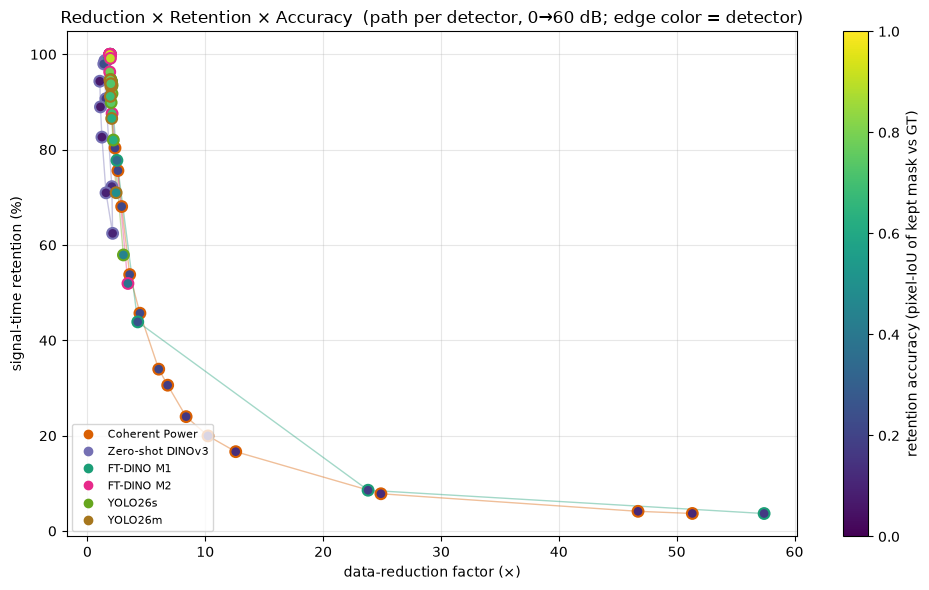

In [7]:
frame = pd.read_csv(TABLES/"frame_pixel_metrics.csv")
iou_by = (frame.groupby(["detector","attenuation_db"])["iou"].mean().reset_index()
          .rename(columns={"iou":"pixel_iou"}))
ds = ds.merge(iou_by, on=["detector","attenuation_db"], how="left")

def fig_bubble(fname="fig_reduction_retention_accuracy.png"):
    fig, ax = plt.subplots(figsize=(10, 6))
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.reduction_x, 100*d.retention, "-", color=COLOR[det], alpha=.4, lw=1)
        sc = ax.scatter(d.reduction_x, 100*d.retention, c=d.pixel_iou, cmap="viridis",
                        vmin=0, vmax=1, s=60, edgecolor=COLOR[det], linewidth=1.5, zorder=3)
    cb = fig.colorbar(sc, ax=ax); cb.set_label("retention accuracy (pixel-IoU of kept mask vs GT)")
    ax.set_xlabel("data-reduction factor (×)"); ax.set_ylabel("signal-time retention (%)")
    ax.set_title("Reduction × Retention × Accuracy  (path per detector, 0→60 dB; edge color = detector)")
    handles=[plt.Line2D([],[],color=COLOR[d],marker='o',ls='',label=LABEL[d]) for d in DETS]
    ax.legend(handles=handles, fontsize=8, loc="lower left"); ax.grid(alpha=.3); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
fig_bubble()

## 2. Compute cost (FLOPs + GPU memory + real-time throughput)
From `compute_table.csv`. `realtime_x` = sustained throughput ÷ the 938 tiles/s needed to keep up
with 245.76 MS/s (≥1 = real-time capable on one GPU). Coherent/zero-shot are estimates.

,model,params_M,gflops_per_tile,gflops_per_s_realtime,gpu_mem_mb,realtime_x,src
0,finetuned_dino_m1,87.6,91.43,85715.6,512,0.091,offline
1,finetuned_dino_m2,87.6,91.43,85715.6,511,0.091,offline
2,cuda_dino_zeroshot,87.6,91.43,85715.6,512,0.091,container(est)
3,yolo26m,20.4,173.69,162834.4,662,0.171,offline
4,coherent_power,0.0,0.01,9.4,50,inf,container(est)


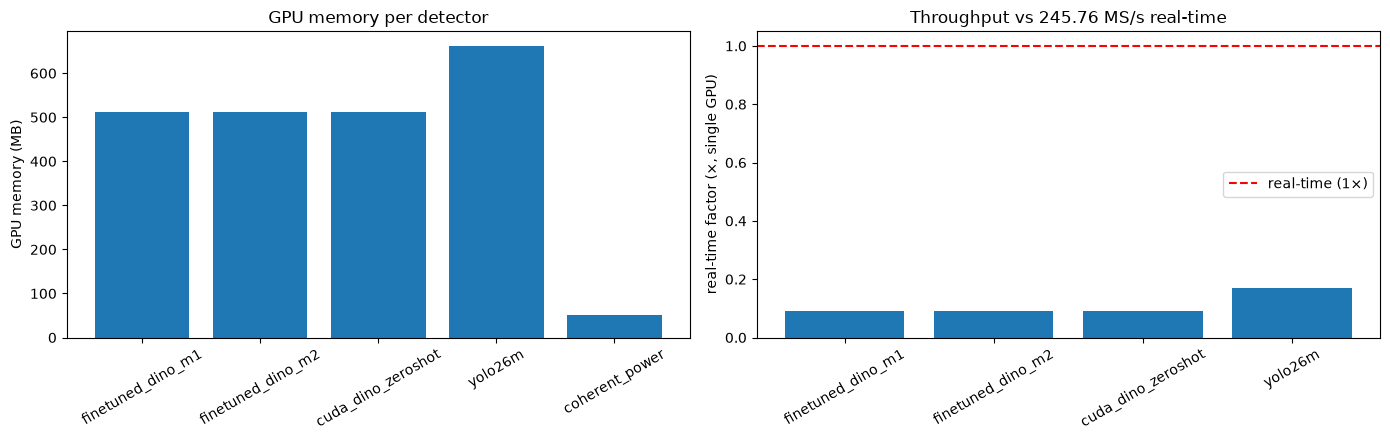

In [8]:
comp = pd.read_csv(COMPUTE_CSV)
display(comp[["model","params_M","gflops_per_tile","gflops_per_s_realtime","gpu_mem_mb","realtime_x","src"]])
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
c=[COLOR.get(m.replace("_zeroshot","").replace("_m1","").replace("finetuned_dino","finetuned_dino"),"#888") for m in comp.model]
ax[0].bar(comp.model, comp.gpu_mem_mb); ax[0].set_ylabel("GPU memory (MB)"); ax[0].set_title("GPU memory per detector")
rt=comp.replace([np.inf],np.nan); ax[1].bar(rt.model, rt.realtime_x); ax[1].axhline(1,color="r",ls="--",label="real-time (1×)")
ax[1].set_ylabel("real-time factor (×, single GPU)"); ax[1].set_title("Throughput vs 245.76 MS/s real-time"); ax[1].legend()
for a in ax: a.tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig("fig_compute.png",dpi=110,bbox_inches="tight"); display(fig); plt.close(fig)

## Figure 2 — detection performance (IoU) vs SNR, paired with compute cost
Model pixel-IoU vs attenuation (line per model); compute table above is the cost side of the trade-off.

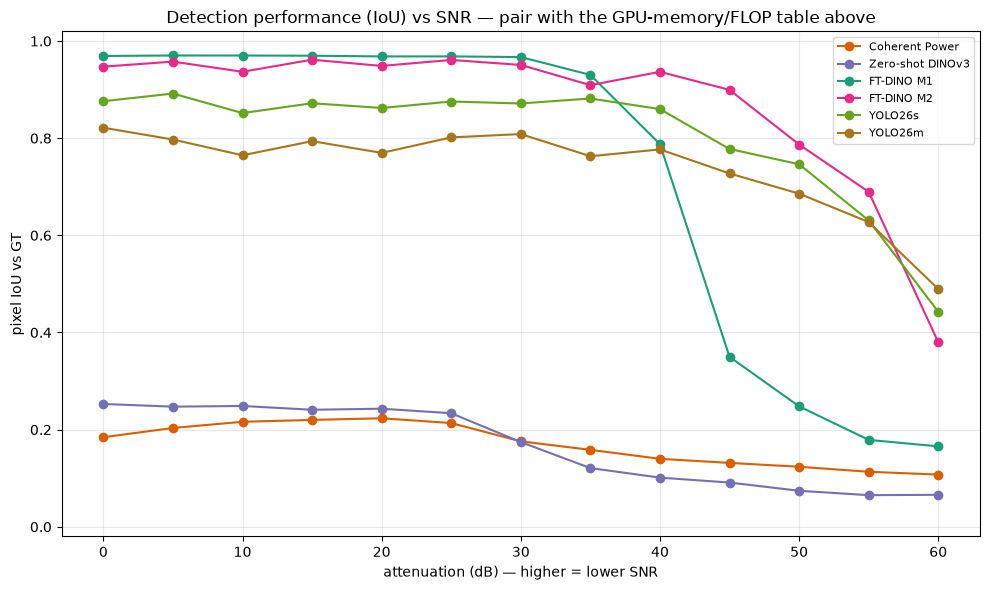

In [9]:
def fig2(fname="fig2_iou_vs_snr.png"):
    fig, ax = plt.subplots(figsize=(10, 6))
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, d.pixel_iou, "-o", color=COLOR[det], label=LABEL[det])
    ax.set_xlabel("attenuation (dB) — higher = lower SNR"); ax.set_ylabel("pixel IoU vs GT")
    ax.set_ylim(-.02, 1.02); ax.grid(alpha=.3); ax.legend(fontsize=8)
    ax.set_title("Detection performance (IoU) vs SNR — pair with the GPU-memory/FLOP table above")
    fig.tight_layout(); fig.savefig(fname,dpi=110,bbox_inches="tight"); display(fig); plt.close(fig)
fig2()

## Extra — the real-time benefit vs naive capture-everything
Cumulative TB/hour saved by time-slicing (per detector), i.e. `SAVE_ALL − time-slice`.

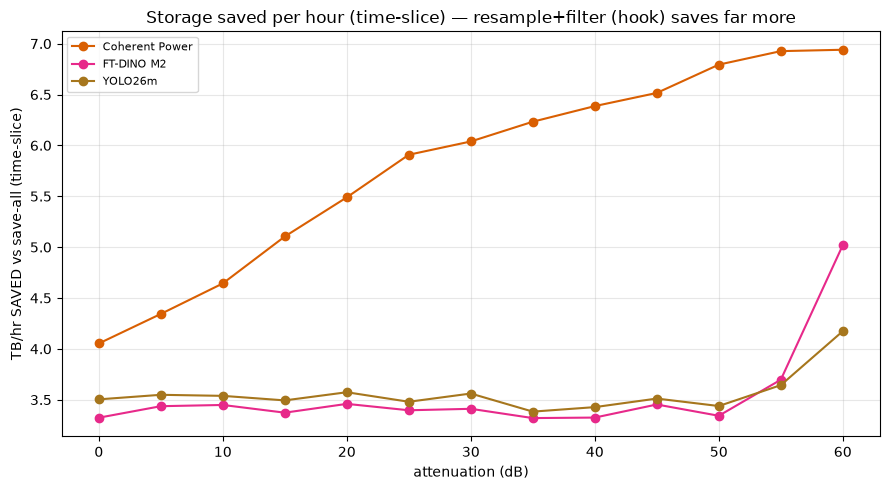

In [10]:
def fig_saved(fname="fig_tb_saved.png"):
    fig, ax = plt.subplots(figsize=(9,5))
    for det in ("coherent_power","finetuned_dino_m2","yolo26m"):
        d=ds[ds.detector==det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, d.saveall_TB_hr-d.timeslice_TB_hr, "-o", color=COLOR[det], label=LABEL[det])
    ax.set_xlabel("attenuation (dB)"); ax.set_ylabel("TB/hr SAVED vs save-all (time-slice)")
    ax.set_title("Storage saved per hour (time-slice) — resample+filter (hook) saves far more")
    ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(fname,dpi=110,bbox_inches="tight"); display(fig); plt.close(fig)
fig_saved()

## Figure 3 — LIVE OTA data (dense bursty 2.4 GHz traffic)
On-the-air capture at **2.45 GHz center, 200 MHz BW** (WiFi/BLE — dense, bursty). Bars: naive +
5 detectors; y = **stored bytes/hour (log)** via time-slicing. Dense traffic = little signal-free
time, so time-slicing saves *less* here (bars sit near naive) — motivating the resample+filter
(frequency) approach. `coherent_power` + zero-shot DINO are container-only (no live masks) → hatched
"pending". No ground truth on live data, so this is stored-bytes only (no retention).

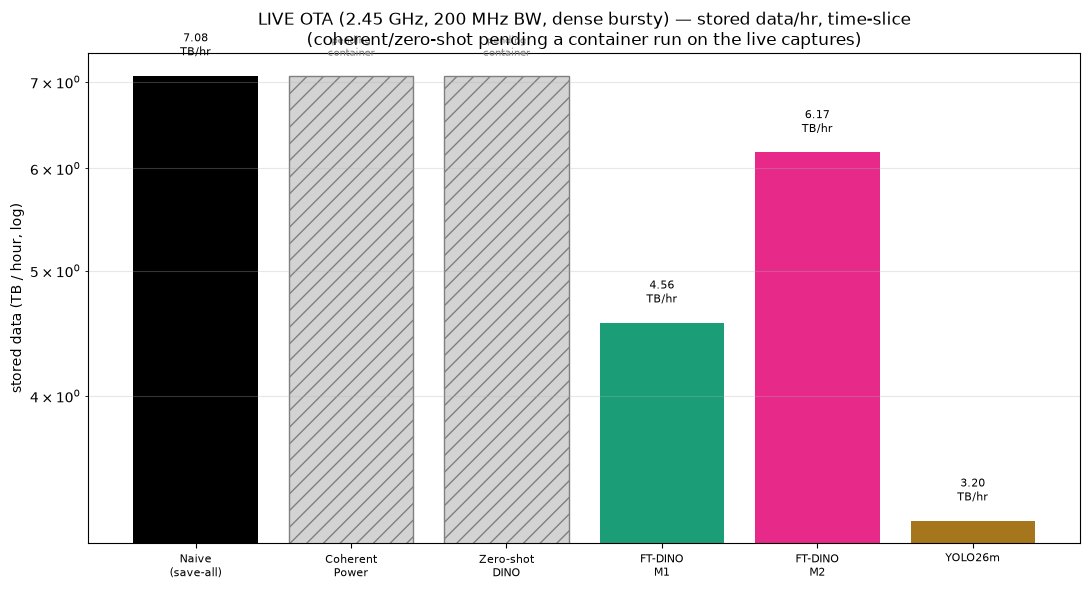

In [11]:
live = pd.read_csv("live_data_saving.csv")
_order = ["naive_save_all","coherent_power","cuda_dino_zeroshot","finetuned_dino","finetuned_dino_m2","yolo26m"]
live = live.set_index("model").reindex(_order).reset_index()
_lab = {"naive_save_all":"Naive\n(save-all)","coherent_power":"Coherent\nPower","cuda_dino_zeroshot":"Zero-shot\nDINO",
        "finetuned_dino":"FT-DINO\nM1","finetuned_dino_m2":"FT-DINO\nM2","yolo26m":"YOLO26m"}
def fig3(fname="fig3_live_ota_bytes.png"):
    fig, ax = plt.subplots(figsize=(11, 6)); base = SAVE_ALL_BYTES_HR/1e12
    for i, r in live.iterrows():
        v = r.stored_TB_hr_timeslice
        if r.status == "pending(container)" or not np.isfinite(v):
            ax.bar(i, base, color="lightgray", hatch="//", edgecolor="gray")
            ax.text(i, base*1.03, "pending\ncontainer", ha="center", va="bottom", fontsize=7, color="gray")
        else:
            ax.bar(i, v, color=("k" if r.model=="naive_save_all" else COLOR.get(r.model, "#4477aa")))
            ax.text(i, v*1.03, f"{v:.2f}\nTB/hr", ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log"); ax.set_xticks(range(len(live))); ax.set_xticklabels([_lab[m] for m in live.model], fontsize=8)
    ax.set_ylabel("stored data (TB / hour, log)")
    ax.set_title("LIVE OTA (2.45 GHz, 200 MHz BW, dense bursty) — stored data/hr, time-slice\n(coherent/zero-shot pending a container run on the live captures)")
    ax.grid(alpha=.3, axis="y", which="both"); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
fig3()

Variation: time-slice vs resample+filter (projected) on the OTA data, per offline model.

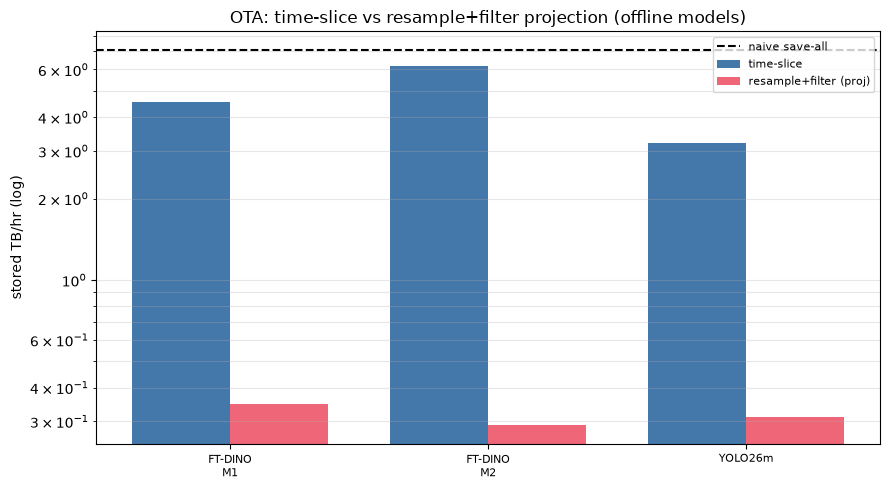

In [12]:
def fig3b(fname="fig3b_live_ota_resample.png"):
    av = live[live.status == "offline"]; xs = np.arange(len(av)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(xs-w/2, av.stored_TB_hr_timeslice, w, label="time-slice", color="#4477aa")
    ax.bar(xs+w/2, av.stored_TB_hr_resample_proj, w, label="resample+filter (proj)", color="#ee6677")
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="k", ls="--", label="naive save-all")
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels([_lab[m] for m in av.model], fontsize=8)
    ax.set_ylabel("stored TB/hr (log)"); ax.set_title("OTA: time-slice vs resample+filter projection (offline models)")
    ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y", which="both"); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
fig3b()

## Figure 3c — OTA resample+filter **MEASURED** (real signal_snipper output)
Bars = actual snipped-SigMF bytes/hr from running `signal_snipper` (frequency mode) offline over the
live captures, vs the raw-mask-coverage projection. A model shows a measured bar only once its snipper
run exists under `SNIP_ROOT/<detector>/<stem>/snippets/`; otherwise it is hatched "pending(snipper)".
Run: `sudo env CONTAINER_NAME=<container> applications/usrp_wideband_signal_detection/bash_scripts/run_offline_snipper.sh`
(add `DETECTOR=cuda_dino` for the zero-shot DINO masks), then re-run this notebook.

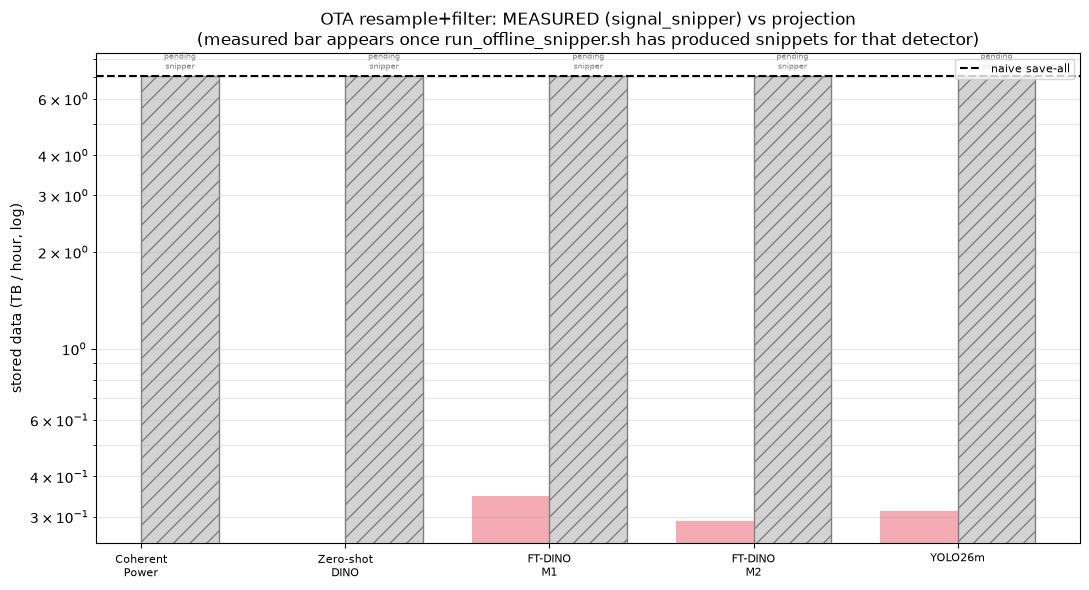

fig3c: measured resample+filter for 0/5 models (run bash_scripts/run_offline_snipper.sh for the rest)


In [13]:
OTA_STEMS   = os.environ.get("DS_OTA_STEMS", "test_1,test_2,test_3").split(",")
OTA_CAP_SEC = float(os.environ.get("DS_OTA_CAP_SEC", "3.0"))   # 5.9 GB cf32 @ 245.76 MS/s = 3.0 s/file
_snip_det   = {"coherent_power":"coherent_power","cuda_dino_zeroshot":"cuda_dino",
               "finetuned_dino":"finetuned_dino","finetuned_dino_m2":"finetuned_dino_m2","yolo26m":"yolo26m"}

def ota_resample_meas_TB_hr(model):
    det = _snip_det.get(model)
    if det is None:
        return np.nan
    tot, found = 0, False
    for st in OTA_STEMS:
        b = snippet_bytes(det, st)
        if b is not None:
            tot += b; found = True
    return (tot / (OTA_CAP_SEC * len(OTA_STEMS)) * SEC_PER_HR / 1e12) if found else np.nan

def fig3c(fname="fig3c_live_ota_resample_measured.png"):
    models = [m for m in _order if m != "naive_save_all"]
    xs, w = np.arange(len(models)), 0.38
    fig, ax = plt.subplots(figsize=(11, 6))
    meas = {m: ota_resample_meas_TB_hr(m) for m in models}
    proj = {r.model: r.get("stored_TB_hr_resample_proj", np.nan) for _, r in live.iterrows()}
    for i, m in enumerate(models):
        pv = proj.get(m, np.nan)
        if np.isfinite(pv):
            ax.bar(xs[i]-w/2, pv, w, color="#ee6677", alpha=.55,
                   label=("resample+filter (proj)" if i == 0 else None))
        mv = meas[m]
        if np.isfinite(mv):
            ax.bar(xs[i]+w/2, mv, w, color="#228833",
                   label=("resample+filter (MEASURED)" if i == 0 else None))
            ax.text(xs[i]+w/2, mv*1.05, f"{mv:.3g}", ha="center", va="bottom", fontsize=7)
        else:
            ax.bar(xs[i]+w/2, SAVE_ALL_BYTES_HR/1e12, w, color="lightgray", hatch="//", edgecolor="gray")
            ax.text(xs[i]+w/2, (SAVE_ALL_BYTES_HR/1e12)*1.03, "pending\nsnipper",
                    ha="center", va="bottom", fontsize=6, color="gray")
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="k", ls="--", label="naive save-all")
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels([_lab[m] for m in models], fontsize=8)
    ax.set_ylabel("stored data (TB / hour, log)")
    ax.set_title("OTA resample+filter: MEASURED (signal_snipper) vs projection\n"
                 "(measured bar appears once run_offline_snipper.sh has produced snippets for that detector)")
    ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=.3, axis="y", which="both"); fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
    n_meas = sum(np.isfinite(v) for v in meas.values())
    print(f"fig3c: measured resample+filter for {n_meas}/{len(models)} models "
          f"({'run bash_scripts/run_offline_snipper.sh for the rest' if n_meas < len(models) else 'all present'})")
fig3c()

## Caveats & hooks
1. **Resample+filter has two forms here.** Figures 1/3b use a *projection* (raw-mask TF-coverage);
   Figure 3c uses the **measured** `signal_snipper` output via `resample_filter_bytes_per_hour(detector,
   stem, capture_sec)` (now wired to the real operator, not a stub). Produce measurements with
   `applications/usrp_wideband_signal_detection/bash_scripts/run_offline_snipper.sh` (container/lab-admin),
   then re-run — measured bars replace the "pending(snipper)" placeholders.
2. **Metrics are on the DENOISED mask** (components < `MIN_BOX_PIXELS`=256 dropped, matching the
   snipper). Raw "any on-pixel per row" over-counts speckle: at high attenuation it kept ~all the
   time (see `fig_timeslice_raw_vs_denoised`). Denoising fixes coherent_power (att 60: keep ~0.47 -> ~0.02);
   cuda_dino still keeps ~all the time from persistent tone-streaks (a real zero-shot property).
   **Retention is time-based** (fraction of the signal's time-rows kept); coherent-power is the baseline
   to beat. Time-slice granularity is a knob (`timeslice_frac(block_rows=...)`).
3. **Compute FLOPs are estimates** (ViT-B scaled for DINO, ultralytics for YOLO, FFT for coherent);
   GPU memory measured for the offline models; container detectors (coherent, zero-shot) estimated.
4. Numbers use `DS_NFRAMES` frames/stem (default 120); set higher for the final figures.